## GCN to predict binding affinity

In [1]:
# # Althougth !which python showed venv2, import sys, print(sys.path) didn't show path to venv2 site-packages
import sys
print(sys.path)
sys.path.append('/dcs/22/u2243582/cs310/venv2/lib64/python3.12/site-packages')
# # These fixed...
# Even tried without module load python-ml but still same situation..!

['/dcs/22/u2243582/cs310/gen_graphs', '', '/local/java/python-ml/22-12-21-python3.9/lib/python3.9/site-packages', '/local/java/python-ml/22-12-21-python3.9/lib64/python3.9/site-packages', '/usr/lib64/python39.zip', '/usr/lib64/python3.9', '/usr/lib64/python3.9/lib-dynload', '/dcs/22/u2243582/.local/lib/python3.9/site-packages', '/usr/lib64/python3.9/site-packages', '/usr/lib/python3.9/site-packages']


In [2]:
import torch
import numpy as np
import time
import torch_geometric
import matplotlib.pyplot as plt
import networkx as nx
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
import json
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool
import torch.nn as nn
import torch.optim as optim
from torch_geometric.loader import DataLoader
from sklearn.model_selection import KFold
import random
from torch.utils.data import Dataset
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import mean_absolute_error, r2_score

In [3]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


### Load the graphs:

In [4]:
graphs = torch.load("/dcs/22/u2243582/cs310/gen_graphs/final_3dprotein_2dligand_graphs.pkl", weights_only=False)
print(f"Loaded {len(graphs)} complexes")

Loaded 5081 complexes


In [5]:
with open("/dcs/22/u2243582/cs310/gen_graphs/all_binding_data.json", "r") as json_file:
    bindingAff = json.load(json_file)
print(len(bindingAff))

5316


## GCN model:

In [6]:
class GCNEncoder(nn.Module):
    def __init__(self, in_channels, hidden_dim1, hidden_dim2, dropout):
        super(GCNEncoder, self).__init__()
        
        # 2 hidden layers
        self.conv1 = GCNConv(in_channels, hidden_dim1)
        self.conv2 = GCNConv(hidden_dim1, hidden_dim2)
        self.conv3 = GCNConv(hidden_dim2, hidden_dim2*2)
        self.conv4 = GCNConv(hidden_dim2*2, hidden_dim2)

        self.dropout = nn.Dropout(dropout)
        self.relu = nn.ReLU()

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.conv2(x, edge_index)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.conv3(x, edge_index)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.conv4(x, edge_index)

        # Pooling to get graph-level embedding
        x = global_mean_pool(x, batch)

        return x

In [7]:
class MLP(nn.Module):
    def __init__(self, input_dim, dropout):
        super(MLP, self).__init__()
        
        self.fc1 = nn.Linear(input_dim, input_dim*2)
        self.fc2 = nn.Linear(input_dim*2, input_dim)
        self.fc3 = nn.Linear(input_dim, 1)
        
        self.dropout = nn.Dropout(dropout)
        self.relu = nn.ReLU()
        
    def forward(self, x):
        
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        
        x = self.relu(self.fc2(x))
        
        x = self.fc3(x)
        return x

In [8]:
class BindingAffinityGNN(torch.nn.Module):
    def __init__(self, protein_in, ligand_in, hidden_dim1, hidden_dim2, dropout):
        super(BindingAffinityGNN, self).__init__()
        
        # Use the GCNEncoder with two hidden layers
        self.protein_encoder = GCNEncoder(protein_in, hidden_dim1, hidden_dim2, dropout)
        self.ligand_encoder = GCNEncoder(ligand_in, hidden_dim1, hidden_dim2, dropout)
        
        # MLP with 2 hidden layers for final prediction
        self.mlp = MLP(2*hidden_dim2, dropout)

    def forward(self, protein_data, ligand_data):
        # Encode protein and ligand graphs
        protein_emb = self.protein_encoder(protein_data.x, protein_data.edge_index, protein_data.batch)
        ligand_emb = self.ligand_encoder(ligand_data.x, ligand_data.edge_index, ligand_data.batch)
        
        # Concatenate the embeddings and pass through MLP
        combined = torch.cat([protein_emb, ligand_emb], dim=1)  # Concatenate embeddings
        output = self.mlp(combined)
        
        return output

In [9]:
def train(model, train_loader, val_loader, criterion, optimizer, patience=12, epochs=60):
    model.to(device)
    best_loss = float("inf")
    patience_counter = 0
    epoch_losses = []

    for epoch in range(epochs):
        model.train()
        train_loss = 0

        for batch in train_loader:
            protein_data, ligand_data, y_batch = batch
            protein_data, ligand_data, y_batch = (
                protein_data.to(device),
                ligand_data.to(device),
                y_batch.to(device),
            )

            optimizer.zero_grad()
            #y_pred = model(protein_data, ligand_data).squeeze()
            y_pred = model(protein_data, ligand_data).view(-1)
            y_batch = y_batch.view(-1)

            loss = criterion(y_pred, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)
        epoch_losses.append(avg_train_loss)

        # ---- Validation Step ----
        model.eval()
        val_loss = 0

        with torch.no_grad():
            for batch in val_loader:
                protein_data, ligand_data, y_val_batch = batch
                protein_data, ligand_data, y_val_batch = (
                    protein_data.to(device),
                    ligand_data.to(device),
                    y_val_batch.to(device),
                )

                #y_val_pred = model(protein_data, ligand_data).squeeze()
                y_val_pred = model(protein_data, ligand_data).view(-1)
                y_val_batch = y_val_batch.view(-1)
                
                loss = criterion(y_val_pred, y_val_batch)
                val_loss += loss.item()

        avg_val_loss = val_loss / len(val_loader)

        #print(f"Epoch {epoch+1}: Train Loss = {avg_train_loss:.4f}, Val Loss = {avg_val_loss:.4f}")

        # ---- Early Stopping ----
        if avg_val_loss < best_loss:
            best_loss = avg_val_loss
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

    return epoch_losses

In [10]:
# ---- Custom Dataset to Handle Graph Data ----
class GraphDataset(Dataset):
    def __init__(self, graph_dict, label_dict, keys):
        self.graph_dict = graph_dict
        self.label_dict = label_dict
        self.keys = keys  # List of selected keys (codes)

    def __len__(self):
        return len(self.keys)

    def __getitem__(self, idx):
        code = self.keys[idx]  # Get code from stored keys
        protein_graph, ligand_graph = self.graph_dict[code]  # Get graphs
        label = torch.tensor(float(self.label_dict[code][1]), dtype=torch.float32)  # Get label

        return protein_graph, ligand_graph, label

In [11]:
# Convert Dictionary Keys into a List 
all_codes = list(graphs.keys())  # List of codes

In [12]:
param_grid = {
    "hidden_dim1": [128, 256, 512, 1024],
    "hidden_dim2": [128, 256, 512, 1024],
    "dropout": [0.1, 0.2, 0.3, 0.4],
    "learning_rate": [0.0001, 0.0005, 0.001, 0.005],
    "weight_decay": [0, 1e-6, 1e-5, 1e-4],
}

kf_outer = KFold(n_splits=5, shuffle=True, random_state=1)

all_loss_curves = []
results = []

for fold, (train_idx, test_idx) in enumerate(kf_outer.split(all_codes)):
    print(f"Outer Fold {fold+1}/5")

    # Extract Train/Test Codes 
    train_codes = [all_codes[i] for i in train_idx]
    test_codes = [all_codes[i] for i in test_idx]

    random_params = [
        {key: random.choice(values) for key, values in param_grid.items()}
        for _ in range(3)
    ]

    best_params = None
    best_val_loss = float("inf")
    inner_kf = KFold(n_splits=3, shuffle=True, random_state=1)

    # ---- Inner Loop: Hyperparameter Tuning ----
    for params in random_params:
        val_losses = []
        print(f"Running {params}")

        for train_inner_idx, val_idx in inner_kf.split(train_codes):
            train_inner_codes = [train_codes[i] for i in train_inner_idx]
            val_codes = [train_codes[i] for i in val_idx]

            # ---- Create Dataloaders ----
            train_dataset = GraphDataset(graphs, bindingAff, train_inner_codes)
            val_dataset = GraphDataset(graphs, bindingAff, val_codes)

            train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
            val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

            # ---- Initialize Model ----
            model = BindingAffinityGNN(
                protein_in=20,
                ligand_in=1,
                hidden_dim1=params["hidden_dim1"],
                hidden_dim2=params["hidden_dim2"],
                dropout=params["dropout"]
            ).to(device)

            criterion = torch.nn.MSELoss()
            optimizer = torch.optim.Adam(model.parameters(), lr=params["learning_rate"], weight_decay=params["weight_decay"])

            # ---- Train the Model ----
            epoch_losses = train(model, train_loader, val_loader, criterion, optimizer)
            val_losses.append(min(epoch_losses))

        # ---- Track Best Hyperparameters ----
        mean_val_loss = np.mean(val_losses)
        if mean_val_loss < best_val_loss:
            best_val_loss = mean_val_loss
            best_params = params

    print(f"Best hyperparams for Fold {fold+1}: {best_params}")

    # ---- Train Final Model on Outer Train Set ----
    train_dataset = GraphDataset(graphs, bindingAff, train_codes)
    test_dataset = GraphDataset(graphs, bindingAff, test_codes)

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

    model = BindingAffinityGNN(
        protein_in=20,
        ligand_in=1,
        hidden_dim1=best_params["hidden_dim1"],
        hidden_dim2=best_params["hidden_dim2"],
        dropout=best_params["dropout"]
    ).to(device)

    criterion = torch.nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=best_params["learning_rate"], weight_decay=best_params["weight_decay"])

    epoch_losses = train(model, train_loader, test_loader, criterion, optimizer)
    all_loss_curves.append(epoch_losses)

    # ---- Evaluate Model ----
    model.eval()
    y_pred_list, y_true_list = [], []

    with torch.no_grad():
        for protein_graph, ligand_graph, y_batch in test_loader:
            protein_graph = protein_graph.to(device)
            ligand_graph = ligand_graph.to(device)
            y_batch = y_batch.to(device)

#             y_pred = model(protein_graph, ligand_graph).squeeze().cpu().numpy()
#             y_true = y_batch.squeeze().cpu().numpy()

#             y_pred_list.extend(y_pred)
#             y_true_list.extend(y_true)

            y_pred = model(protein_graph, ligand_graph).view(-1).cpu().numpy()  # Ensure 1D shape
            y_true = y_batch.view(-1).cpu().numpy()  # Ensure 1D shape

            y_pred_list.extend(y_pred.tolist())  # Convert numpy to list
            y_true_list.extend(y_true.tolist())  # Convert numpy to list

    # ---- Compute Metrics ----
    pearson_corr, pearson_p = pearsonr(y_true_list, y_pred_list)
    spearman_corr, spearman_p = spearmanr(y_true_list, y_pred_list)
    mae = mean_absolute_error(y_true_list, y_pred_list)
    variance = np.var(np.array(y_true_list) - np.array(y_pred_list))
    r2 = r2_score(y_true_list, y_pred_list)

    results.append({
        "Fold": fold+1,
        "Pearson": pearson_corr, "Pearson p": pearson_p,
        "Spearman": spearman_corr, "Spearman p": spearman_p,
        "MAE": mae, "Variance": variance, "R2": r2
    })
    print(results[fold])

Outer Fold 1/5
Running {'hidden_dim1': 1024, 'hidden_dim2': 256, 'dropout': 0.3, 'learning_rate': 0.0001, 'weight_decay': 1e-06}
Early stopping at epoch 35
Early stopping at epoch 46
Early stopping at epoch 26
Running {'hidden_dim1': 1024, 'hidden_dim2': 128, 'dropout': 0.4, 'learning_rate': 0.0001, 'weight_decay': 1e-05}
Early stopping at epoch 48
Early stopping at epoch 28
Early stopping at epoch 49
Running {'hidden_dim1': 512, 'hidden_dim2': 512, 'dropout': 0.4, 'learning_rate': 0.0005, 'weight_decay': 1e-06}
Early stopping at epoch 48
Early stopping at epoch 48
Best hyperparams for Fold 1: {'hidden_dim1': 512, 'hidden_dim2': 512, 'dropout': 0.4, 'learning_rate': 0.0005, 'weight_decay': 1e-06}
Early stopping at epoch 48
{'Fold': 1, 'Pearson': 0.5974275146882524, 'Pearson p': 2.0709178526408374e-99, 'Spearman': 0.5892356682206068, 'Spearman p': 4.254846560616354e-96, 'MAE': 1.24262475076561, 'Variance': 2.5042510086002983, 'R2': 0.33890527755336575}
Outer Fold 2/5
Running {'hidden_di

In [13]:
print(results)

[{'Fold': 1, 'Pearson': 0.5974275146882524, 'Pearson p': 2.0709178526408374e-99, 'Spearman': 0.5892356682206068, 'Spearman p': 4.254846560616354e-96, 'MAE': 1.24262475076561, 'Variance': 2.5042510086002983, 'R2': 0.33890527755336575}, {'Fold': 2, 'Pearson': 0.604068371939237, 'Pearson p': 4.5543281497142486e-102, 'Spearman': 0.579249642710432, 'Spearman p': 4.2665136299404324e-92, 'MAE': 1.2616957041222279, 'Variance': 2.544689320943752, 'R2': 0.323817552247763}, {'Fold': 3, 'Pearson': 0.5998235106026469, 'Pearson p': 2.6676024148829147e-100, 'Spearman': 0.5790192105209357, 'Spearman p': 5.232044247782141e-92, 'MAE': 1.2618494679139356, 'Variance': 2.4698742247193954, 'R2': 0.33546469192652706}, {'Fold': 4, 'Pearson': 0.5857601189149302, 'Pearson p': 1.2514265260494493e-94, 'Spearman': 0.5785098618703594, 'Spearman p': 8.20841241059916e-92, 'MAE': 1.2453057697908145, 'Variance': 2.48512174319209, 'R2': 0.3383999109150927}, {'Fold': 5, 'Pearson': 0.5837565252285388, 'Pearson p': 7.63726

In [14]:
# Nested CV Extract metrics
pearson_scores = [result['Pearson'] for result in results]
spearman_scores = [result['Spearman'] for result in results]
mae_scores = [result['MAE'] for result in results]
var_scores = [result['Variance'] for result in results]
r2_scores = [result['R2'] for result in results]
pearson_p_values = [result['Pearson p'] for result in results]
spearman_p_values = [result['Spearman p'] for result in results]

# Calculate means and standard deviations
pearson_mean = np.mean(pearson_scores)
pearson_std = np.std(pearson_scores)

spearman_mean = np.mean(spearman_scores)
spearman_std = np.std(spearman_scores)

mae_mean = np.mean(mae_scores)
mae_std = np.std(mae_scores)

var_mean = np.mean(var_scores)
var_std = np.std(var_scores)

r2_mean = np.mean(r2_scores)
r2_std = np.std(r2_scores)

pearson_p_mean = np.mean(pearson_p_values)
pearson_p_std = np.std(pearson_p_values)

spearman_p_mean = np.mean(spearman_p_values)
spearman_p_std = np.std(spearman_p_values)

# Print the results
print(f"Pearson Correlation: Mean = {pearson_mean}, Std = {pearson_std}, p-value Mean = {pearson_p_mean}, p-value Std = {pearson_p_std}")
print(f"Spearman Correlation: Mean = {spearman_mean}, Std = {spearman_std}, p-value Mean = {spearman_p_mean}, p-value Std = {spearman_p_std}")
print(f"MAE: Mean = {mae_mean}, Std = {mae_std}")
print(f"Variance: Mean = {var_mean}, Std = {var_std}")
print(f"R2: Mean = {r2_mean}, Std = {r2_std}")

Pearson Correlation: Mean = 0.594167208274721, Std = 0.007996472582809491, p-value Mean = 1.777743547532268e-94, p-value Std = 2.9695813520381645e-94
Spearman Correlation: Mean = 0.5772982051054342, Std = 0.009313496491943535, p-value Mean = 8.387820223590644e-86, p-value Std = 1.6775631593483607e-85
MAE: Mean = 1.252545072902721, Std = 0.008034975828135902
Variance: Mean = 2.512394484433661, Std = 0.03389456266786106
R2: Mean = 0.32285919847434014, Std = 0.023226654874179308


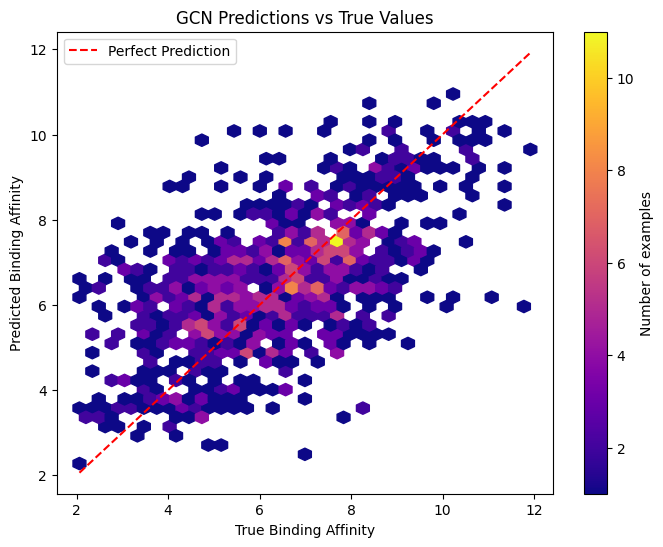

In [15]:
# Create hexbin plot
plt.figure(figsize=(8, 6))
hb = plt.hexbin(y_true_list, y_pred_list, gridsize=35, cmap='plasma', mincnt=1)

# Add a colorbar to indicate density
cb = plt.colorbar(hb)
cb.set_label('Number of examples')

# Add labels and title
plt.xlabel("True Binding Affinity")
plt.ylabel("Predicted Binding Affinity")
plt.title("GCN Predictions vs True Values")

# Add a diagonal line y = x to show the ideal prediction
min_val = min(min(y_true_list), min(y_pred_list))
max_val = max(max(y_true_list), max(y_pred_list))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Prediction')

# Add legend
plt.legend()

# Show the plot
plt.show()

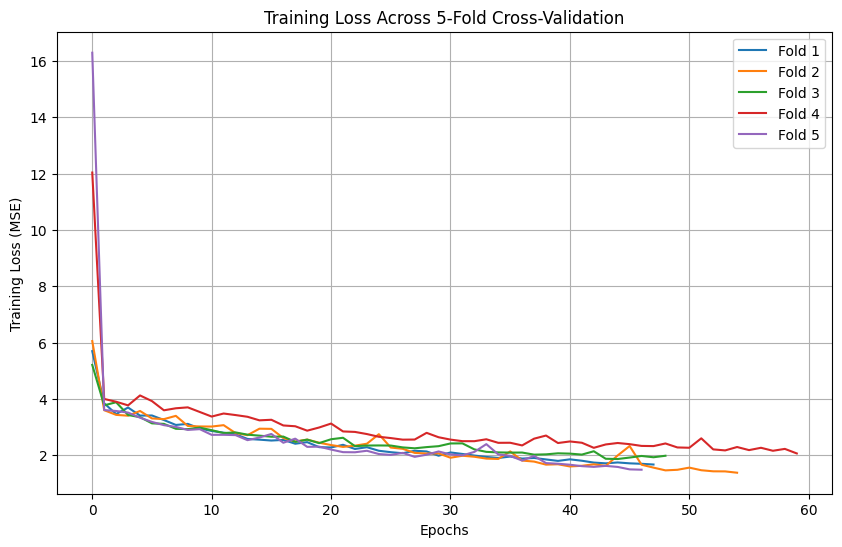

In [ ]:
plt.figure(figsize=(10, 6))
for i, losses in enumerate(all_loss_curves):
    plt.plot(losses, label=f'Fold {i+1}')
plt.xlabel("Epochs")
plt.ylabel("Training Loss (MSE)")
plt.title("Training Loss Across 5-Fold Cross-Validation")
plt.legend()
plt.grid(True)
plt.show()